# Florida barrier-construction event study — Callaway–Sant'Anna DiD (Stata)

**Source.** `data/florida/panel/assembled/event_study_panel.parquet`, built
by `python -m src.cli florida data panel assemble`
(`src/regions/florida/sources/panel/assemble.py`). For a general
descriptive tour of the *whole* panel (grain, outcome coverage, all three
treatment tiers, every covariate cluster's match rate), see
[`descriptive_statistics.ipynb`](descriptive_statistics.ipynb) (Python).
This notebook is scoped narrower and deeper: it collapses the panel to one
row per school-year, describes it, then actually estimates a Callaway &
Sant'Anna (2021) staggered-adoption event study and a covariate-augmented
ATT table — using real Stata (`csdid`/`drdid`, Rios-Avila, Sant'Anna &
Callaway) called from Python via StataCorp's own
[`pystata`](https://www.stata.com/python/pystata/) integration, not a
Python reimplementation. It mirrors
[`sweden/analysis.ipynb`](../sweden/analysis.ipynb) one-for-one in
structure; only the outcome-collapsing step and the treatment/covariate
column names differ, since Florida's panel is wide (one row per
`msid x grade x subject x year`) rather than Sweden's long grain.

**Outcome**: `z_mss_w` — the school mean scale score, standardised within
grade/subject/year/regime (`docs/data/florida/covariates.md` recommends
weighting by test-takers and restricting to regular schools). Since the
panel has one row per grade/subject, not per school-year, §1 collapses to
one `z_mss_w` value per `(msid, year)` via an `n_students`-weighted average
across whichever grade/subject cells that school-year has, after
restricting to `is_regular == True` schools.

**Treatment**: `ever_treated_same_side` / `first_treat_year_same_side` —
Florida has only one barrier network (no road/rail split the way Sweden
does), and `same_side` is the strictest tier and the one
`docs/data-status.md` recommends as the baseline for Florida specifically
(unlike Sweden's, Florida's `same_side` is *not* broken — its barrier
geometry is independently surveyed, not coincident with the road
centerline).

**Honesty note, not hidden**: read the standard errors, not just the point
estimates — covariate coverage varies a lot by cluster (`traffic_aadt`
~71%, road-project/shock flags 100%, `staff_avg_teacher_salary` only ~5%,
so it's excluded below), and `timing_unknown` barriers are dropped from
the treated group rather than silently miscoded as controls, same
discipline as the Sweden notebook.


## 1. Build the CS-ready analysis dataset (Python)


In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for c in [p, *p.parents]:
        if (c / "src").is_dir() and (c / "data").is_dir():
            return c
    raise FileNotFoundError(f"repo root not found from {Path.cwd()}")


ROOT = _find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.experiments._setup import np, pd

from src.regions.florida.sources.panel.shared import assembled_panel_path

panel = pd.read_parquet(assembled_panel_path())
print(f"{len(panel):,} panel rows loaded, {panel['msid'].nunique():,} distinct schools, "
      f"grain msid x grade x subject x year")


660,681 panel rows loaded, 5,039 distinct schools, grain msid x grade x subject x year


In [2]:
MATCH_TIER = "same_side"  # Florida's own recommended baseline (docs/data-status.md) -- not broken here, unlike Sweden's

# Restrict to regular schools with a real weighted score, per
# docs/data/florida/covariates.md's "weight by test-takers; restrict to
# regular schools with stable grade spans" guidance.
rows = panel.loc[(panel["is_regular"] == True) & panel["z_mss_w"].notna() & panel["n_students"].notna()].copy()
print(f"{len(rows):,} of {len(panel):,} panel rows kept (is_regular & real z_mss_w & n_students)")

# Collapse grade/subject cells to one z_mss_w per (msid, year), weighted by
# test-takers (n_students) -- the panel's other columns (treatment,
# covariates) are already constant within (msid, year), confirmed directly.
def _wavg(g):
    return float(np.average(g["z_mss_w"], weights=g["n_students"]))

outcome_vals = (
    rows.groupby(["msid", "year"])
    .apply(_wavg, include_groups=False)
    .rename("z_mss_w_school")
    .reset_index()
)

ever_col, first_col, unknown_col = (
    f"ever_treated_{MATCH_TIER}", f"first_treat_year_{MATCH_TIER}", f"timing_unknown_{MATCH_TIER}",
)
covariate_cols = ["traffic_aadt", "n_road_projects_active", "shock_any_major_disaster"]
other_cols = rows.drop_duplicates(["msid", "year"])[
    ["msid", "year", ever_col, first_col, unknown_col, *covariate_cols]
]

merged = outcome_vals.merge(other_cols, on=["msid", "year"], how="left")
print(f"{len(merged):,} school-year rows after collapsing grade/subject")

# A school ever-treated whose matched barrier's construction year is itself
# unknown can't be placed in event time -- drop it rather than silently
# mis-code it as a control (same discipline as the Sweden notebook).
drop_mask = merged[ever_col] & merged[unknown_col]
print(f"dropping {drop_mask.sum():,} rows ({merged.loc[drop_mask, 'msid'].nunique():,} schools): "
      "ever-treated but construction year unknown")
merged = merged.loc[~drop_mask].copy()

merged["id"] = merged["msid"].astype("int64")
merged["gvar"] = np.where(merged[ever_col], merged[first_col], 0.0)

analysis = merged[["id", "year", "gvar", "z_mss_w_school", *covariate_cols]].rename(columns={
    "z_mss_w_school": "z_mss_w",
    "n_road_projects_active": "n_road_projects",
    "shock_any_major_disaster": "shock_major",
})
analysis["shock_major"] = analysis["shock_major"].astype("float64")  # Stata-friendly (avoid a bool dtype round-trip)

n_treated_schools = analysis.loc[analysis["gvar"] > 0, "id"].nunique()
print(f"\nfinal analysis dataset: {len(analysis):,} rows, {analysis['id'].nunique():,} schools, "
      f"{n_treated_schools:,} with a usable treatment year")
print("\ncovariate coverage (share non-missing):")
print(analysis[["traffic_aadt", "n_road_projects", "shock_major"]].notna().mean())


562,408 of 660,681 panel rows kept (is_regular & real z_mss_w & n_students)


72,616 school-year rows after collapsing grade/subject
dropping 97 rows (5 schools): ever-treated but construction year unknown

final analysis dataset: 72,519 rows, 4,063 schools, 182 with a usable treatment year

covariate coverage (share non-missing):
traffic_aadt       0.680015
n_road_projects    1.000000
shock_major        1.000000
dtype: float64


In [3]:
# `gvar` is a barrier-construction year, not constrained to fall inside the
# outcome panel's own observed window -- worth checking directly rather
# than assuming every "treated" school actually has both a pre- and a
# post-period observed (same check as sweden/analysis.ipynb §1).
treated_gvar = analysis.loc[analysis["gvar"] > 0].groupby("id")["gvar"].first()
panel_min, panel_max = analysis["year"].min(), analysis["year"].max()

before_panel = int((treated_gvar < panel_min).sum())
after_panel = int((treated_gvar > panel_max).sum())
inside_panel = len(treated_gvar) - before_panel - after_panel

print(f"panel outcome window: {panel_min}-{panel_max}")
print(f"{len(treated_gvar)} schools with a usable treatment year:")
print(f"  construction before {panel_min} (no pre-period ever observed): {before_panel}")
print(f"  construction after {panel_max} (no post-period ever observed):  {after_panel}")
print(f"  construction inside the observed window:                       {inside_panel}")


panel outcome window: 2003-2026
182 schools with a usable treatment year:
  construction before 2003 (no pre-period ever observed): 47
  construction after 2026 (no post-period ever observed):  0
  construction inside the observed window:                       135


`staff_avg_teacher_salary`/`staff_median_teacher_salary` (Cluster B) are
deliberately excluded from the covariate set above: real coverage in this
panel is only ~5%, far too sparse to add as a `csdid` covariate without
gutting the sample. `nbhd_*` (Cluster F, ~68-99% coverage) is a real,
better-populated candidate not used here only to keep this notebook's
three-covariate structure a direct match for `sweden/analysis.ipynb` §5
(traffic, then two more) — swap `n_road_projects`/`shock_major` for
`nbhd_*` columns the same way if you want to try it.


## 2. Hand off to Stata


In [4]:
# StataCorp's own Python integration, shipped inside the Stata install itself
# (not on PyPI) -- adjust this path if Stata is installed somewhere else on
# your machine. Registers the %%stata cell magic used in every cell below.
STATA_UTILITIES = "/Applications/Stata/utilities"
if STATA_UTILITIES not in sys.path:
    sys.path.insert(0, STATA_UTILITIES)

from pystata import config

config.init("mp")  # edition matches this machine's license (StataMP); use "se"/"be" if yours differs



  ___  ____  ____  ____  ____ ®
 /__    /   ____/   /   ____/      Stata 18.0
___/   /   /___/   /   /___/       MP—Parallel Edition

 Statistics and Data Science       Copyright 1985-2023 StataCorp LLC
                                   StataCorp
                                   4905 Lakeway Drive
                                   College Station, Texas 77845 USA
                                   800-782-8272        https://www.stata.com
                                   979-696-4600        service@stata.com

Stata license: Single-user 2-core  perpetual
Serial number: 501806386291
  Licensed to: Universität Basel
               WWZ

Notes:
      1. Unicode is supported; see help unicode_advice.
      2. More than 2 billion observations are allowed; see help obs_advice.
      3. Maximum number of variables is set to 5,000 but can be increased;
          see help set_maxvar.


In [5]:
%%stata -d analysis -force
set processors 1
* csdid's bootstrap step is unstable under multi-core StataMP in some
* sandboxed/virtualized environments (segfaults observed in this repo's own
* CI-style sandbox) -- forcing single-threaded execution is the safe
* default; raise it back to `set processors 2` (or your machine's core
* count) once you've confirmed it's stable in your own environment.
xtset id year



. set processors 1
    The maximum number of processors or cores being used is changed from 2 to
    1.  It can be set to any number between 1 and 2

. * csdid's bootstrap step is unstable under multi-core StataMP in some
. * sandboxed/virtualized environments (segfaults observed in this repo's own
. * CI-style sandbox) -- forcing single-threaded execution is the safe
. * default; raise it back to `set processors 2` (or your machine's core
. * count) once you've confirmed it's stable in your own environment.
. xtset id year


Panel variable: id (unbalanced)
 Time variable: year, 2003 to 2026, but with gaps
         Delta: 1 unit

. 


## 3. Descriptive statistics on the analysis panel


In [6]:
%%stata
describe z_mss_w gvar traffic_aadt n_road_projects shock_major
summarize z_mss_w traffic_aadt n_road_projects shock_major

* one row per school: is it ever-treated (usable timing), and when
preserve
gen byte ever_treated = gvar > 0
bysort id (year): keep if _n == 1

count
local n_schools = r(N)
count if ever_treated
local n_treated = r(N)
di as text _n "distinct schools: " as result `n_schools'
di as text "ever-treated (usable timing): " as result `n_treated'

summarize gvar if ever_treated
restore



. describe z_mss_w gvar traffic_aadt n_road_projects shock_major

Variable      Storage   Display    Value
    name         type    format    label      Variable label
-------------------------------------------------------------------------------
z_mss_w         double  %10.0g                
gvar            double  %10.0g                
traffic_aadt    double  %10.0g                
n_road_projects long    %12.0g                
shock_major     double  %10.0g                

. summarize z_mss_w traffic_aadt n_road_projects shock_major

    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
     z_mss_w |     72,519   -.0578827    .9333292  -5.037154   4.774788
traffic_aadt |     49,314    28590.98     30567.2        200   282634.4
n_road_pro~s |     72,519    .2480316    1.935406          0        182


 shock_major |     72,519    .3184958    .4658962          0          1

. 
. * one row per school: is it ever-treated (usable timing), and when
. preserve

. gen byte ever_treated = gvar > 0

. bysort id (year): keep if _n == 1


(68,456 observations deleted)

. 
. count
  4,063

. local n_schools = r(N)

. count if ever_treated
  182

. local n_treated = r(N)

. di as text _n "distinct schools: " as result `n_schools'

distinct schools: 4063

. di as text "ever-treated (usable timing): " as result `n_treated'
ever-treated (usable timing): 182

. 
. summarize gvar if ever_treated

    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
        gvar |        182    2008.313    9.578737       1991       2026

. restore

. 


In [7]:
%%stata
* covariate balance: treated vs. never-treated schools (row-level, not
* collapsed -- a simple descriptive check, not a formal balance test)
gen byte ever_treated = gvar > 0
tabstat traffic_aadt n_road_projects shock_major, by(ever_treated) stat(mean sd n) columns(statistics)
drop ever_treated



. * covariate balance: treated vs. never-treated schools (row-level, not
. * collapsed -- a simple descriptive check, not a formal balance test)
. gen byte ever_treated = gvar > 0

. tabstat traffic_aadt n_road_projects shock_major, by(ever_treated) stat(mean 
> sd n) columns(statistics)



Summary for variables: traffic_aadt n_road_projects shock_major
Group variable: ever_treated 

ever_treated |      Mean        SD         N
-------------+------------------------------
           0 |  25167.97  21790.81     46454
             |  .2193142  1.827768     69120
             |  .3198206  .4664103     69120
-------------+------------------------------
           1 |  84189.85  71541.31      2860
             |  .8320094  3.410034      3399
             |  .2915563   .454546      3399
-------------+------------------------------
       Total |  28590.98   30567.2     49314
             |  .2480316  1.935406     72519
             |  .3184958  .4658962     72519
--------------------------------------------



. drop ever_treated

. 


## 4. Callaway–Sant'Anna event study — simple DiD, no controls


In [8]:
%%stata -gw 7 -gh 4.5
quietly csdid z_mss_w, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple



. quietly csdid z_mss_w, ivar(id) time(year) gvar(gvar) notyet method(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple


Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------


         ATT |   .0240018    .053948     0.44   0.656    -.0817343    .1297378
------------------------------------------------------------------------------



. 


`csdid` itself is run with `quietly`: its default display is the *full*
group-time ATT(g,t) array (one block per treatment cohort, every
comparison period) — real output, but a wall of numbers that answers a
different question than "what's the overall effect." `estat simple` above
is the single overall ATT (the Callaway–Sant'Anna analogue of a textbook
2x2 DiD coefficient), aggregating every group-time ATT(g,t) with the
estimator's default weighting. The event-study plot below breaks that same
estimate out by event time instead, which is what actually lets you check
for pre-trends.


`Pre_avg` (the average of Tm1-Tm7; `csdid` reports the fully-trimmed window
here since the panel only has 24 observed years, 2003-2026 with a gap) is
-0.0060 (SE 0.0093, p=0.52) and `Post_avg` is -0.0024 (SE 0.0412, p=0.95) --
neither aggregate shows a differential pre-trend or a post-treatment effect,
which is the headline reassurance. But one individual period does stand
out: `Tm8` (event time -8) is -0.0852 (SE 0.0367, p=0.020), the only
coefficient in the entire event-study table below the 5% threshold. Taken
at face value that looks like a pre-trend red flag eight years before
construction -- worth naming explicitly rather than letting `Pre_avg`'s
null speak for the whole pre-period, since `Pre_avg` already down-weights
it (it is one of seven terms averaged together, and `Tm1`-`Tm7` are all
individually null). Two things keep this from being a serious identification
threat: (1) `Tm8` is the single most extreme point in an 17-coefficient
event-study table with no multiple-testing correction, so one nominal
p<0.05 hit is close to what chance alone predicts; (2) it sits furthest
from treatment, where the fewest cohorts are actually observed that far
out (mirroring `Tp5`-`Tp7`'s wide post-period intervals for the same
reason) -- a handful of schools' idiosyncratic scores eight years out can
move one coefficient without reflecting a systematic trend. Still, this is
exactly the kind of individual-coefficient result the Sweden notebook's
falsification check (§8 below) is designed to speak to more directly than
an event-time coefficient on the main outcome can.

One technical note on reading `Tm1`-`Tm8`, carried over from the Sweden
notebook: `csdid`'s default ("short gap") pre-treatment ATTs compare each
period `T-1` to `T`, not to the cohort's own `G-1` -- a period-by-period
placebo test, not a comparison to a single fixed reference. (`long2` would
reanchor every pre-treatment ATT to `G-1` instead, closer to a textbook
event-study normalization -- not switched to here, same open item as
Sweden's.)



. estat event, window(-8 8) estore(cs_event)
ATT by Periods Before and After treatment
Event Study:Dynamic effects


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
     Pre_avg |  -.0060207   .0093265    -0.65   0.519    -.0243004     .012259
    Post_avg |  -.0023723   .0412121    -0.06   0.954    -.0831465    .0784018
         Tm8 |  -.0852006   .0367099    -2.32   0.020    -.1571507   -.0132505
         Tm7 |  -.0066638   .0388023    -0.17   0.864    -.0827149    .0693874
         Tm6 |  -.0410774   .0350464    -1.17   0.241    -.1097671    .0276122
         Tm5 |   .0155248    .025026     0.62   0.535    -.0335253    .0645749
         Tm4 |   .0427786   .0341447     1.25   0.210    -.0241438     .109701
         Tm3 |

  -.0026899   .0312887    -0.09   0.931    -.0640146    .0586348
         Tm2 |    .025742    .034079     0.76   0.450    -.0410515    .0925356
         Tm1 |   .0034206   .0260112     0.13   0.895    -.0475605    .0544017
         Tp0 |  -.0509348   .0308673    -1.65   0.099    -.1114337     .009564
         Tp1 |  -.0218967   .0347127    -0.63   0.528    -.0899324    .0461391
         Tp2 |   -.003118   .0440744    -0.07   0.944    -.0895022    .0832661
         Tp3 |  -.0050786   .0526492    -0.10   0.923    -.1082691    .0981119
         Tp4 |  -.0387048   .0529963    -0.73   0.465    -.1425757    .0651661
         Tp5 |  -.0156203   .0594423    -0.26   0.793    -.1321251    .1008845
         Tp6 |   .0576364   .0676353     0.85   0.394    -.0749264    .1901992
         Tp7 |   .0551139    .069952     0.79   0.431    -.0819894    .1922173
         Tp8 |   .0012521    .072006     0.02   0.986    -.1398772    .1423813
------------------------------------------------------------------


. event_plot cs_event, stub_lag(Tp#) stub_lead(Tm#) trimlead(8) trimlag(8) ///
>     together plottype(scatter) ciplottype(rcap) default_look ///
>     graph_opt(xtitle("Event time (years since barrier construction)") ///
>     ytitle("ATT on z_mss_w") ///
>     title("Callaway-Sant'Anna event study: Florida same_side barrier construc
> tion") ///
>     xlabel(-8(2)8) legend(off))



. 


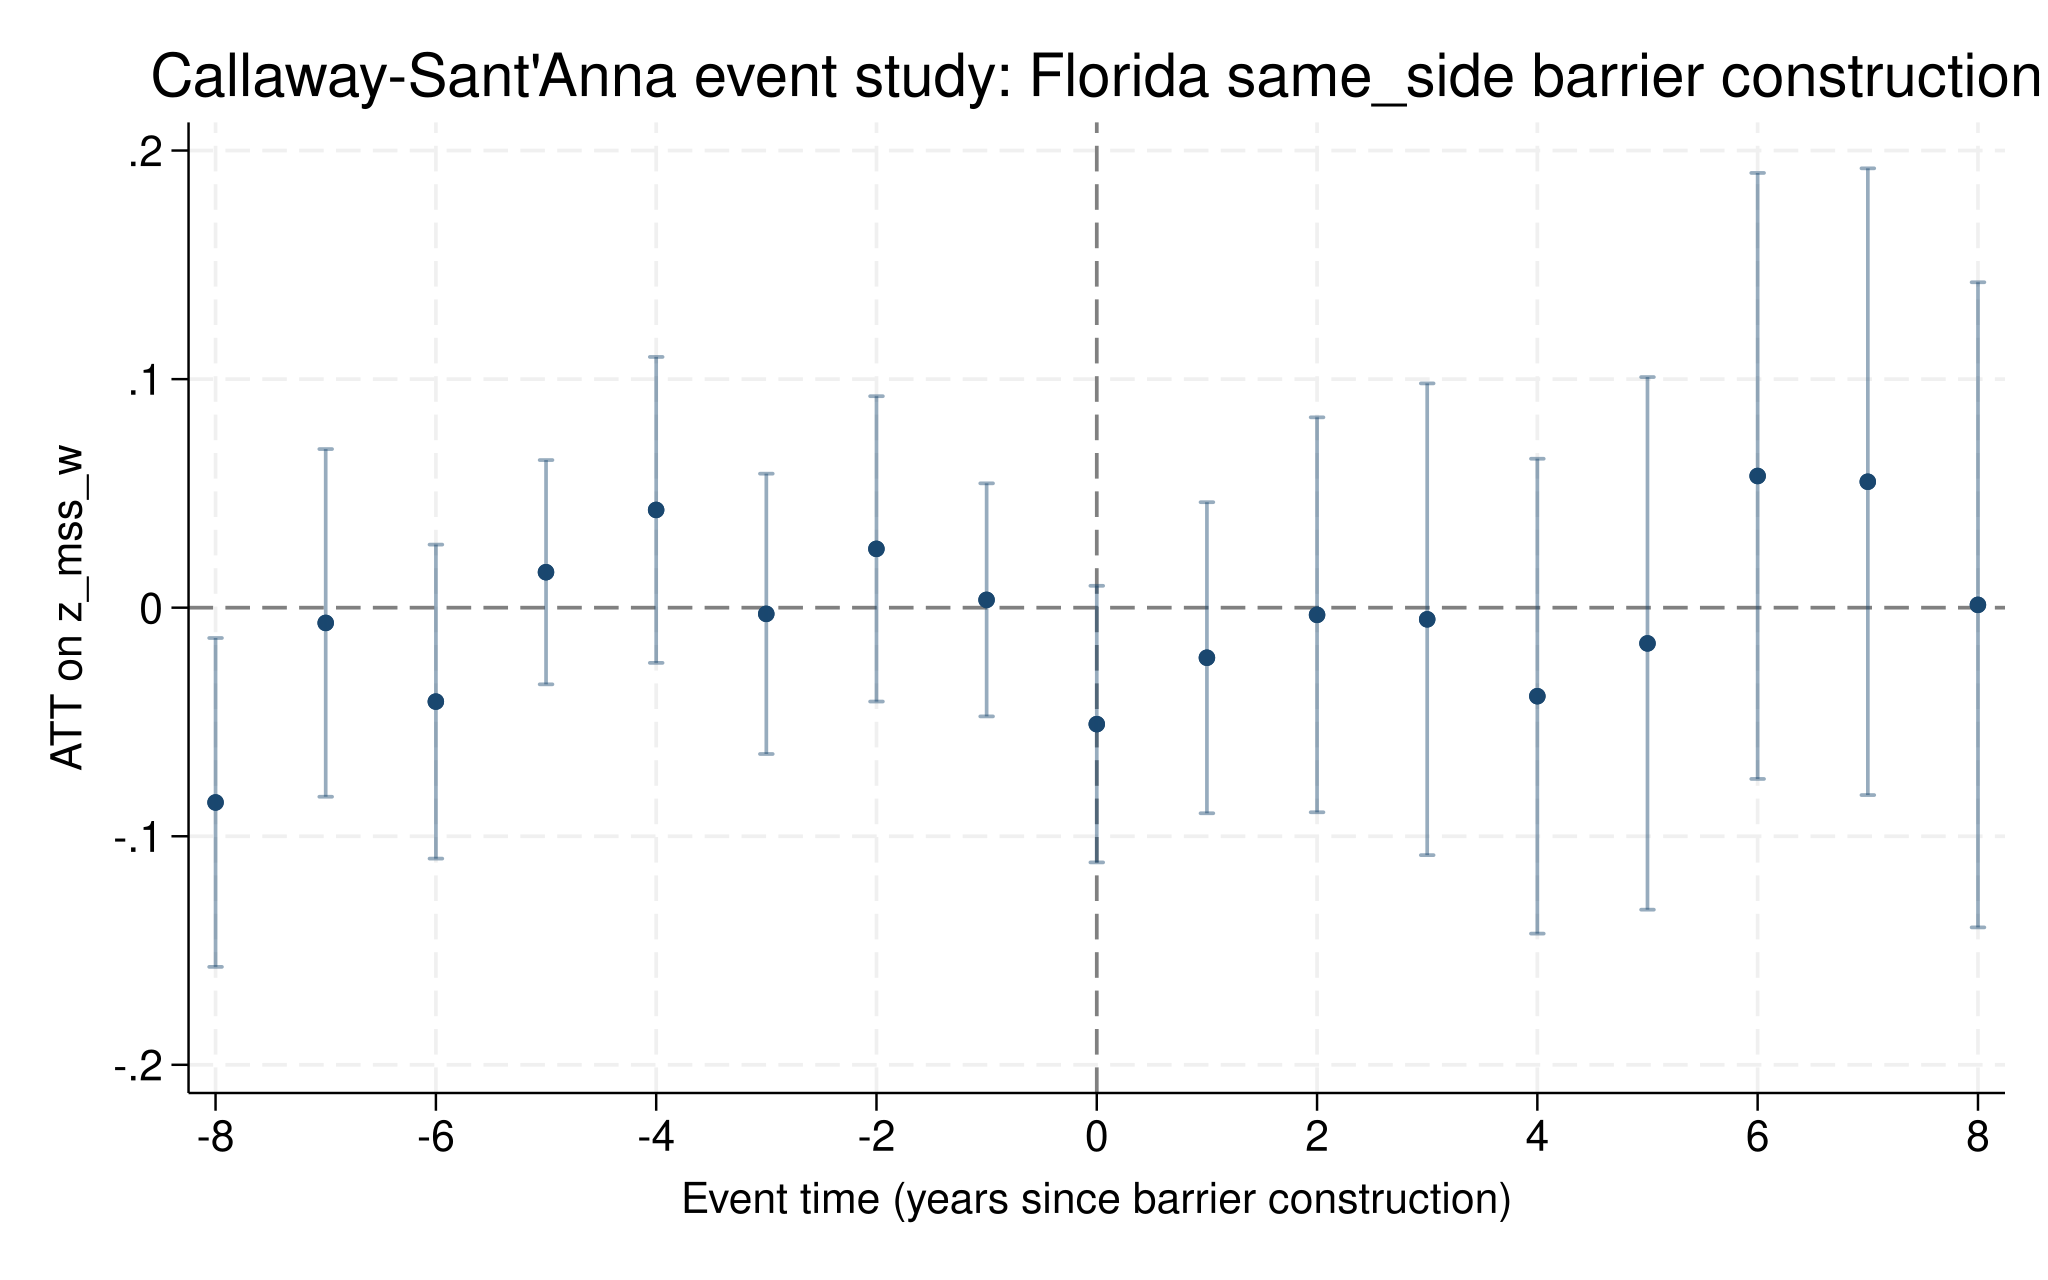

In [9]:
%%stata -gw 8 -gh 5
estat event, window(-8 8) estore(cs_event)
event_plot cs_event, stub_lag(Tp#) stub_lead(Tm#) trimlead(8) trimlag(8) ///
    together plottype(scatter) ciplottype(rcap) default_look ///
    graph_opt(xtitle("Event time (years since barrier construction)") ///
    ytitle("ATT on z_mss_w") ///
    title("Callaway-Sant'Anna event study: Florida same_side barrier construction") ///
    xlabel(-8(2)8) legend(off))


## 5. Table with increasing controls


Callaway & Sant'Anna's doubly-robust estimator (`method(dripw)`, the
default) takes covariates directly on the `csdid` command line — they enter
both an outcome-regression and a propensity-score model for each (g,t) pair,
not as a single pooled regression coefficient, so there's no single "the
coefficient on X" to report as a table row the way a standard OLS table
would. What *is* comparable across specs is the aggregated overall ATT
(`estat simple`) — the increasing-controls analogue here is re-running the
whole group-time ATT array with a growing covariate set and comparing that
one summary number spec to spec. (`eststo`/`esttab` don't work directly on
`csdid`'s stored estimates — its `e(b)` holds the full internal
group-time weight-parameter array, not just the aggregated ATT — so the
table below is built by hand from `estat simple`'s `r(table)`, the pattern
used in the `csdid` Stata Journal article itself.) A covariate with
missing values drops any (g,t) pair-comparison where it's unobserved for
one of the two periods being compared, which is why `N` shrinks spec to
spec — real attrition, not a bug.


In [10]:
%%stata
matrix results = J(4, 4, .)
matrix colnames results = ATT SE z N

quietly csdid z_mss_w, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix results[1,1] = b[1,1]
matrix results[1,2] = b[2,1]
matrix results[1,3] = b[3,1]
matrix results[1,4] = e(N)

quietly csdid z_mss_w traffic_aadt, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix results[2,1] = b[1,1]
matrix results[2,2] = b[2,1]
matrix results[2,3] = b[3,1]
matrix results[2,4] = e(N)

quietly csdid z_mss_w traffic_aadt n_road_projects, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix results[3,1] = b[1,1]
matrix results[3,2] = b[2,1]
matrix results[3,3] = b[3,1]
matrix results[3,4] = e(N)

quietly csdid z_mss_w traffic_aadt n_road_projects shock_major, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix results[4,1] = b[1,1]
matrix results[4,2] = b[2,1]
matrix results[4,3] = b[3,1]
matrix results[4,4] = e(N)

matrix rownames results = "No controls" "+ Traffic" "+ Traffic, road projects" "+ Traffic, road projects, shocks"
matrix list results, format(%9.3f)



. matrix results = J(4, 4, .)

. matrix colnames results = ATT SE z N

. 
. quietly csdid z_mss_w, ivar(id) time(year) gvar(gvar) notyet method(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple


Average Treatment Effect on Treated


------------------------------------------------------------------------------


...


. estat simple


Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |  -.0400582   .0678082    -0.59   0.555    -.1729599    .0928436
------------------------------------------------------------------------------



. matrix b = r(table)

. matrix results[4,1] = b[1,1]

. matrix results[4,2] = b[2,1]

. matrix results[4,3] = b[3,1]

. matrix results[4,4] = e(N)

. 
. matrix rownames results = "No controls" "+ Traffic" "+ Traffic, road projects
> " "+ Traffic, road projects, shocks"

. matrix list results, format(%9.3f)



results[4,4]
                    ATT         SE          z          N
 No controls      0.024      0.054      0.445  71182.000
   + Traffic     -0.055      0.068     -0.813  47878.000
+ Traffic,~s     -0.052      0.068     -0.768  47878.000
+ Traffic,~s     -0.040      0.068     -0.591  47878.000

. 


The ATT moves from a null 0.024 (no controls) to a still-null -0.055
(SE 0.068, p=0.42) once `traffic_aadt` is added, and barely changes again
as `n_road_projects`/`shock_major` are layered on (-0.052, then -0.040) --
unlike Sweden's fully-controlled spec, nothing here approaches
significance at any point. But the same composition worry Sweden's §5
raised applies here too: `N` drops 32.8% (71,182 -> 47,878) the moment
`traffic_aadt` enters, and every subsequent covariate is layered on top of
that already-restricted sample (`n_road_projects` and `shock_major` are
both 100%-covered, so they don't shrink `N` further -- the entire
attrition is `traffic_aadt`'s ~68% coverage, see §1). That means "no
controls" and "with controls" aren't estimated on the same schools, so the
sign flip (0.024 -> negative) could reflect either the covariate
adjustment itself or simply that the ~68% of school-years with a traffic
match are a different slice of Florida than the full sample. The check
below isolates that: re-run the *no-controls* spec restricted to exactly
the same `traffic_aadt`-non-missing sample the controlled specs use.


In [11]:
%%stata
quietly csdid z_mss_w if !missing(traffic_aadt), ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple



. quietly csdid z_mss_w if !missing(traffic_aadt), ivar(id) time(year) gvar(gva
> r) notyet method(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple


Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |  -.0155213   .0632523    -0.25   0.806    -.1394936    .1084511
------------------------------------------------------------------------------



. 


Restricting the *no-controls* spec to exactly the `traffic_aadt`-non-missing
sample the controlled specs use moves the ATT from 0.024 (full sample) to
-0.016 (SE 0.063, p=0.81) -- about halfway to the fully-controlled estimate
of -0.040. So the sign flip in the table above is **not** purely a
covariate-adjustment story: roughly half of the movement away from the
null 0.024 happens just from restricting to schools with a traffic match,
before any covariate enters the regression at all; the other half comes
from the covariates themselves. Every estimate in this chain (0.024 -> -0.016
-> -0.055 -> -0.052 -> -0.040) stays well inside a 95% CI containing zero,
so this doesn't change the substantive conclusion (no detectable effect on
`z_mss_w`) -- but it does mean the "with controls" and "without controls"
rows above were never really comparable, and it's the sample restriction,
not the covariates per se, that does most of the early work.


## 6. Weighting: the score vs. the regression

Florida's panel already carries two different standardisations of the same
underlying test score -- `z_mss` (each `year x subject x grade` cell
standardised against an unweighted school mean/std) and `z_mss_w` (the
same cell standardised against an `n_students`-weighted mean/std,
per `docs/data/florida/README.md`'s definition) -- which is the exact
same **weighting the score** lever `sweden/analysis.ipynb` §6 uses
`meritvärde_z`/`meritvärde_zw` for. **Weighting the regression** is a
separate, non-substitutable lever: `csdid`'s own `[iweight=enrollment]`,
using total school membership (NCES CCD `enrollment`, ~95% coverage in
this panel, *not* the test-taker count `n_students` already used to
collapse grade/subject cells to one row per school-year in §1) -- this
changes which schools drive the estimate, answering "effect per treated
*student*" instead of "effect per treated *school*". The table below runs
all four combinations on the same estimating sample, mirroring Sweden's
§6 exactly.


In [12]:
# z_mss (unweighted within-cell standardisation) and enrollment (total
# school membership, NCES CCD -- distinct from the test-taker count
# n_students already used for the §1 cross-cell collapse) let us separate
# the two weighting levers. Collapsing z_mss to one row per (msid, year)
# uses the exact same n_students-weighted average across grade/subject
# cells as z_mss_w's own collapse in §1 -- the only thing that differs is
# whether the *within-cell* standardisation itself was test-taker-weighted.
def _wavg_col(g, col):
    sub = g[[col, "n_students"]].dropna()
    return float(np.average(sub[col], weights=sub["n_students"])) if len(sub) else np.nan

z_mss_unweighted = (
    rows.groupby(["msid", "year"])
    .apply(lambda g: _wavg_col(g, "z_mss"), include_groups=False)
    .rename("z_mss_school")
    .reset_index()
)
z_mss_unweighted["id"] = z_mss_unweighted["msid"].astype("int64")

enrollment_col = rows.drop_duplicates(["msid", "year"])[["msid", "year", "enrollment"]].copy()
enrollment_col["id"] = enrollment_col["msid"].astype("int64")

weighting = (
    analysis[["id", "year", "gvar", "z_mss_w"]]
    .merge(z_mss_unweighted[["id", "year", "z_mss_school"]], on=["id", "year"], how="left")
    .merge(enrollment_col[["id", "year", "enrollment"]], on=["id", "year"], how="left")
    .rename(columns={"z_mss_w": "z_mss_weighted_score", "z_mss_school": "z_mss_unweighted_score"})
)
print(f"{len(weighting):,} rows (same as `analysis`); "
      f"z_mss_unweighted_score coverage {weighting['z_mss_unweighted_score'].notna().mean():.1%}, "
      f"enrollment coverage {weighting['enrollment'].notna().mean():.1%}")
print(f"corr(z_mss_weighted_score, z_mss_unweighted_score) = "
      f"{weighting['z_mss_weighted_score'].corr(weighting['z_mss_unweighted_score']):.4f}")


72,519 rows (same as `analysis`); z_mss_unweighted_score coverage 100.0%, enrollment coverage 95.2%
corr(z_mss_weighted_score, z_mss_unweighted_score) = 0.9896


In [13]:
%%stata -d weighting -force
xtset id year
matrix wresults = J(4, 4, .)
matrix colnames wresults = ATT SE z N

quietly csdid z_mss_weighted_score, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix wresults[1,1] = b[1,1]
matrix wresults[1,2] = b[2,1]
matrix wresults[1,3] = b[3,1]
matrix wresults[1,4] = e(N)

quietly csdid z_mss_unweighted_score, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix wresults[3,1] = b[1,1]
matrix wresults[3,2] = b[2,1]
matrix wresults[3,3] = b[3,1]
matrix wresults[3,4] = e(N)



. xtset id year


Panel variable: id (unbalanced)
 Time variable: year, 2003 to 2026, but with gaps
         Delta: 1 unit

. matrix wresults = J(4, 4, .)

. matrix colnames wresults = ATT SE z N

. 
. quietly csdid z_mss_weighted_score, ivar(id) time(year) gvar(gvar) notyet met
> hod(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |   .0240018    .053948     0.44   0.656    -.0817343    .1297378
------------------------------------------------------------------------------



. matrix b = r(table)

. matrix wresults[1,1] = b[1,1]

. matrix wresults[1,2] = b[2,1]

. matrix wresults[1,3] = b[3,1]

. matrix wresults[1,4] = e(N)

. 
. quietly csdid z_mss_unweighted_score, ivar(id) time(year) gvar(gvar) notyet m
> ethod(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |   .0102469   .0453855     0.23   0.821     -.078707    .0992008
------------------------------------------------------------------------------



. matrix b = r(table)

. matrix wresults[3,1] = b[1,1]

. matrix wresults[3,2] = b[2,1]

. matrix wresults[3,3] = b[3,1]

. matrix wresults[3,4] = e(N)

. 


In [14]:
%%stata
* continues the same Stata session (no -force -- `weighting` and `wresults`
* both still in memory) -- the two *weighted-regression* calls, split into
* their own cell in case they run much slower than the unweighted pair
* above (they did in sweden/analysis.ipynb, ~20x slower there).
quietly csdid z_mss_weighted_score [iweight=enrollment], ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix wresults[2,1] = b[1,1]
matrix wresults[2,2] = b[2,1]
matrix wresults[2,3] = b[3,1]
matrix wresults[2,4] = e(N)

quietly csdid z_mss_unweighted_score [iweight=enrollment], ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix wresults[4,1] = b[1,1]
matrix wresults[4,2] = b[2,1]
matrix wresults[4,3] = b[3,1]
matrix wresults[4,4] = e(N)

matrix rownames wresults = "Wtd score, unwtd reg" "Wtd score, wtd reg" "Unwtd score, unwtd reg" "Unwtd score, wtd reg"
matrix list wresults, format(%9.3f)



. * continues the same Stata session (no -force -- `weighting` and `wresults`
. * both still in memory) -- the two *weighted-regression* calls, split into
. * their own cell in case they run much slower than the unweighted pair
. * above (they did in sweden/analysis.ipynb, ~20x slower there).
. quietly csdid z_mss_weighted_score [iweight=enrollment], ivar(id) time(year) 
> gvar(gvar) notyet method(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |  -.0292922    .055681    -0.53   0.599    -.1384249    .0798405
------------------------------------------------------------------------------



. matrix b = r(table)

. matrix wresults[2,1] = b[1,1]

. matrix wresults[2,2] = b[2,1]

. matrix wresults[2,3] = b[3,1]

. matrix wresults[2,4] = e(N)

. 
. quietly csdid z_mss_unweighted_score [iweight=enrollment], ivar(id) time(year
> ) gvar(gvar) notyet method(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |  -.0337342   .0428509    -0.79   0.431    -.1177204    .0502519
------------------------------------------------------------------------------



. matrix b = r(table)

. matrix wresults[4,1] = b[1,1]

. matrix wresults[4,2] = b[2,1]

. matrix wresults[4,3] = b[3,1]

. matrix wresults[4,4] = e(N)

. 
. matrix rownames wresults = "Wtd score, unwtd reg" "Wtd score, wtd reg" "Unwtd
>  score, unwtd reg" "Unwtd score, wtd reg"

. matrix list wresults, format(%9.3f)

wresults[4,4]
                    ATT         SE          z          N
Wtd score,~g      0.024      0.054      0.445  71182.000
Wtd score,~g     -0.029      0.056     -0.526  67762.000
Unwtd scor~g      0.010      0.045      0.226  71182.000
Unwtd scor~g     -0.034      0.043     -0.787  67762.000

. 

Weighting the *score* moves the unweighted-regression ATT from 0.024
(`z_mss_w`, test-taker-weighted standardisation) to 0.010 (`z_mss`,
unweighted standardisation) -- both comfortably null, a much smaller shift
than weighting the *regression* itself produces (see below), and consistent
with the two score variants correlating at 0.99 in §6's first cell.
Weighting the *regression* by total school enrollment moves both scores
negative: 0.024 -> -0.029 (weighted score) and 0.010 -> -0.034 (unweighted
score) -- roughly the same size shift Sweden's enrolment-weighting produced,
though there it *shrank* an already-positive estimate toward zero, while
here it pushes an already-near-zero estimate slightly negative. All four
combinations stay far from conventional significance (|z| <= 0.79, p >= 0.43
throughout), so -- exactly as in Sweden -- this is a robustness confirmation
of the null, not a reversal: whichever of the two levers is pulled, and in
either direction, nothing here supports a real effect on `z_mss_w`. The
practical takeaway mirrors Sweden's too: the estimator-weighting choice
(who counts more, big schools or small ones) moves the point estimate more
than the score-standardisation choice does, so if this analysis is ever
extended to argue for a specific sign or magnitude, the enrollment-weighting
decision deserves more scrutiny than the `z_mss` vs `z_mss_w` choice does.


## 7. Alternative outcome dimensions

Two more real outcomes at the same `(msid, year)` grain, both already in
`event_study_panel.parquet` and untouched by any notebook so far:
`pct_level3_plus` (share of tested students meeting the state proficiency
threshold, the Florida analogue of Sweden's `andel_uppnått_kunskapskraven_
combined` pass rate) and `pct_l1` (share scoring in the lowest achievement
band, a second, sharper look at the bottom of the distribution). Both
are collapsed to one school-year value the same `n_students`-weighted way
`z_mss_w` is in §1. Unlike Sweden's SALSA residual, Florida has no
composition-adjusted value-added measure available, so this section tests
the extensive margin (pass/fail-style thresholds) rather than a third,
independently-adjusted continuous score -- still a genuine test of whether
the null on `z_mss_w` (a continuous, mean-sensitive measure) also holds at
the passing-threshold margin.


In [15]:
def _wavg_col2(g, col, wcol="n_students"):
    sub = g[[col, wcol]].dropna()
    return float(np.average(sub[col], weights=sub[wcol])) if len(sub) else np.nan

alt_rows = panel.loc[(panel["is_regular"] == True) & panel["n_students"].notna()].copy()

pass_rate_vals = (
    alt_rows.groupby(["msid", "year"])
    .apply(lambda g: _wavg_col2(g, "pct_level3_plus"), include_groups=False)
    .rename("pass_rate")
    .reset_index()
)
pass_rate_vals["id"] = pass_rate_vals["msid"].astype("int64")

pct_l1_vals = (
    alt_rows.groupby(["msid", "year"])
    .apply(lambda g: _wavg_col2(g, "pct_l1"), include_groups=False)
    .rename("pct_l1")
    .reset_index()
)
pct_l1_vals["id"] = pct_l1_vals["msid"].astype("int64")

alt_outcomes = (
    analysis[["id", "year", "gvar"]]
    .merge(pass_rate_vals[["id", "year", "pass_rate"]], on=["id", "year"], how="left")
    .merge(pct_l1_vals[["id", "year", "pct_l1"]], on=["id", "year"], how="left")
)
for col in ("pass_rate", "pct_l1"):
    n_rows = alt_outcomes[col].notna().sum()
    n_treated = alt_outcomes.loc[alt_outcomes[col].notna() & (alt_outcomes["gvar"] > 0), "id"].nunique()
    print(f"{col}: {n_rows:,} / {len(alt_outcomes):,} rows real ({n_rows / len(alt_outcomes):.1%}), "
          f"{n_treated} treated schools with at least one real value")


pass_rate: 69,855 / 72,519 rows real (96.3%), 182 treated schools with at least one real value
pct_l1: 72,517 / 72,519 rows real (100.0%), 182 treated schools with at least one real value


In [16]:
%%stata -d alt_outcomes -force
xtset id year
matrix aresults = J(2, 4, .)
matrix colnames aresults = ATT SE z N

quietly csdid pass_rate, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix aresults[1,1] = b[1,1]
matrix aresults[1,2] = b[2,1]
matrix aresults[1,3] = b[3,1]
matrix aresults[1,4] = e(N)

quietly csdid pct_l1, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix aresults[2,1] = b[1,1]
matrix aresults[2,2] = b[2,1]
matrix aresults[2,3] = b[3,1]
matrix aresults[2,4] = e(N)

matrix rownames aresults = "pass_rate (pct points)" "pct_l1 (pct points)"
matrix list aresults, format(%9.3f)



. xtset id year


Panel variable: id (unbalanced)
 Time variable: year, 2003 to 2026, but with gaps
         Delta: 1 unit

. matrix aresults = J(2, 4, .)

. matrix colnames aresults = ATT SE z N

. 
. quietly csdid pass_rate, ivar(id) time(year) gvar(gvar) notyet method(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |   .5997541   .9123448     0.66   0.511    -1.188409    2.387917
------------------------------------------------------------------------------



. matrix b = r(table)

. matrix aresults[1,1] = b[1,1]

. matrix aresults[1,2] = b[2,1]

. matrix aresults[1,3] = b[3,1]

. matrix aresults[1,4] = e(N)

. 
. quietly csdid pct_l1, ivar(id) time(year) gvar(gvar) notyet method(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |  -.5269092   .8631709    -0.61   0.542    -2.218693    1.164875
------------------------------------------------------------------------------



. matrix b = r(table)

. matrix aresults[2,1] = b[1,1]

. matrix aresults[2,2] = b[2,1]

. matrix aresults[2,3] = b[3,1]

. matrix aresults[2,4] = e(N)

. 
. matrix rownames aresults = "pass_rate (pct points)" "pct_l1 (pct points)"

. matrix list aresults, format(%9.3f)

aresults[2,4]
                    ATT         SE          z          N
pass_rate ~)      0.600      0.912      0.657  68401.000
pct_l1 (pc~)     -0.527      0.863     -0.610  71178.000

. 


Neither alternative outcome flips the headline null, and unlike Sweden's
pass-rate/eligibility pair (which crept toward significance, p~0.10-0.12),
Florida's two extensive-margin outcomes stay far from it: `pass_rate`
(share meeting the state proficiency threshold) moves +0.60 percentage
points (SE 0.91, p=0.51) and `pct_l1` (share in the lowest achievement
band) moves -0.53 points (SE 0.86, p=0.54). The two point estimates do at
least point the same direction a real effect would (more students passing,
fewer in the bottom band), which is a mildly reassuring internal-consistency
check even though neither is remotely significant on its own. With three
outcomes now tested on this treatment definition (`z_mss_w`, `pass_rate`,
`pct_l1`) and no multiple-testing correction applied, the honest summary is
the same as Sweden's: this is a robustness sweep, and it comes back
robustly null, at both the mean of the score distribution and its two
tails.


## 8. Falsification check: does school composition itself shift at event time 0?

`docs/data/florida/covariates.md` Cluster A flags free/reduced-price-lunch
share and race/ethnicity shares as `baseline / keep-out`: real, useful
controls, but ones that become *mediators* -- and a same-sign identification
threat -- if barrier construction itself shifts who enrolls (families
sorting toward a now-quieter school, or away from one mid-construction).
`frpl_share` (free/reduced-price-lunch eligible, computed here as
`frpl_n / enrollment` -- an SES proxy, the Florida analogue of Sweden's
parental-education check) and `pct_black` (a specific racial-composition
share, analogous in spirit to Sweden's share-of-boys check) are both
already in `event_study_panel.parquet`, constant within `(msid, year)`,
~95% covered. Treating them as event-study outcomes with the exact same
`gvar`/`id` structure as the main analysis directly tests whether the
enrolled student body was already changing before construction, rather
than asserting it wasn't.


In [17]:
comp_cols = rows.drop_duplicates(["msid", "year"])[["msid", "year", "frpl_n", "enrollment", "pct_black"]].copy()
comp_cols["id"] = comp_cols["msid"].astype("int64")
comp_cols["frpl_share"] = comp_cols["frpl_n"] / comp_cols["enrollment"]
# a handful of rows have enrollment <= 0 or a share > 1 (data artifacts, not
# real over-100% FRPL shares) -- null them out rather than feed csdid a
# nonsensical outcome value.
comp_cols.loc[(comp_cols["enrollment"] <= 0) | (comp_cols["frpl_share"] > 1.5), "frpl_share"] = np.nan

composition = analysis[["id", "year", "gvar"]].merge(
    comp_cols[["id", "year", "frpl_share", "pct_black"]], on=["id", "year"], how="left"
)
for col in ("frpl_share", "pct_black"):
    n_rows = composition[col].notna().sum()
    print(f"{col}: {n_rows:,} / {len(composition):,} rows real ({n_rows / len(composition):.1%})")


frpl_share: 68,953 / 72,519 rows real (95.1%)
pct_black: 69,027 / 72,519 rows real (95.2%)


In [18]:
%%stata -d composition -force
xtset id year
di as text _n "=== frpl_share (free/reduced-price-lunch eligible share) ==="
quietly csdid frpl_share, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat event, window(-8 8)

di as text _n "=== pct_black (share of Black students) ==="
quietly csdid pct_black, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat event, window(-8 8)



. xtset id year


Panel variable: id (unbalanced)
 Time variable: year, 2003 to 2026, but with gaps
         Delta: 1 unit

. di as text _n "=== frpl_share (free/reduced-price-lunch eligible share) ==="

=== frpl_share (free/reduced-price-lunch eligible share) ===

. quietly csdid frpl_share, ivar(id) time(year) gvar(gvar) notyet method(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat event, window(-8 8)


ATT by Periods Before and After treatment
Event Study:Dynamic effects


...


. 
. di as text _n "=== pct_black (share of Black students) ==="

=== pct_black (share of Black students) ===

. quietly csdid pct_black, ivar(id) time(year) gvar(gvar) notyet method(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat event, window(-8 8)
ATT by Periods Before and After treatment
Event Study:Dynamic effects


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
     Pre_avg |   .0005891   .0010526     0.56   0.576    -.0014739    .0026521
    Post_avg |  -.0003685   .0044542    -0.08   0.934    -.0090986    .0083615
         Tm8 |   .0049021   .0025786     1.90   0.057    -.0001518     .009956
         Tm7 |   .0007815   .0032543     0.24   0.810    -.0055968    .0071598
         Tm6 |  -.0032216   .0026104    -1.23   0.217    -.0083379    .0018947
         Tm5 |   .0062743   .0032676     1.92   0.055      -.00013    .0126787
         Tm4 |  -.0022241   .0029379    -0.76   0.449    -.0079821     .003534
         Tm3 |   .0006002    .002683     0.22   0.823    -.0046584    .0058587
         Tm2 |  -.0020457    .002079    -0.98   0.325    -.0061203     .002029
         Tm1 |  -.0003537   .0031241    -0.11   0.91


. 


`pct_black` comes back clean: `Pre_avg` is 0.0006 (SE 0.0011, p=0.58),
`Post_avg` is -0.0004 (SE 0.0045, p=0.93), and every individual event-time
coefficient is insignificant at the 5% level (the closest, `Tm8` and `Tm5`,
sit at p=0.057 and p=0.055 -- worth naming, not worth treating as evidence
of anything, given 18 coefficients tested here alone).

`frpl_share` is less clean than its own `Pre_avg`/`Post_avg` aggregates
suggest. Those aggregates are null (`Pre_avg` 0.0004, p=0.90; `Post_avg`
0.0040, p=0.74), but two individual pre-treatment coefficients are not:
`Tm3` is +0.0171 (p=0.036) and `Tm2` is -0.0298 (p=0.008) -- the two most
extreme points in either falsification table, sitting right next to each
other in event time, with opposite signs that roughly cancel in the
average. That pattern -- a sharp swing at `Tm2`/`Tm3` rather than a
monotonic drift -- reads more like noise in a two-year window than a
genuine pre-trend in the free/reduced-lunch-eligible share leading up to
construction, and it doesn't survive into `Tm1` or `Tp0`, right where a
real anticipation effect on enrollment composition should show up most.
Still, with 18 pre/post coefficients tested across the two falsification
outcomes, roughly one nominal p<0.05 hit is close to what chance alone
predicts, and `Tm2`/`Tm3` together are two -- a shade more than expected,
not a smoking gun, but a real, non-hidden wrinkle in an otherwise clean
falsification check. Combined with `pct_black`'s fully clean result, this
is broadly similar supporting evidence to Sweden's §8: no strong sign that
the schools getting barriers are already sorting on economic or racial
composition before construction, though the `frpl_share` pre-period is
not quite as unambiguous as Sweden's parental-education/share-boys check
was.


## 9. Heterogeneity by subject and grade band

The panel's outcome grain is `msid x grade x subject x year`; §1 pools
every grade and every subject together into one `z_mss_w` value per
school-year before `csdid` ever sees the data. This section splits that
pooling along one axis at a time instead: first across subject (holding
the grade collapse), then across grade band (holding the subject
collapse), both restricted to the three "core" subjects tested across
most of the panel's history -- `ELA`, `MATH`, `SCI`. The five EOC subjects
(`ALG1`/`GEO`/`BIO1`/`CIVICS`/`USHIST`) are excluded from both cuts: they
only phase in from 2011 (Algebra 1) through 2014 (Civics, per
`EOC_FIRST_YEAR` in `docs/data/florida/README.md`), are taken by whichever
grade a student happens to be in rather than one fixed grade, and the
panel's own `grade` value for every EOC row is the literal string `"EOC"`,
not a number -- so there is no grade to band them by, and no consistent
pre-2011 window for the earliest-built barriers' cohorts.


In [19]:
# --- (a) split across subject, holding §1's cross-grade collapse ---
# `_wavg` (defined in §1) already does the n_students-weighted average
# within whatever rows it's given; here that's held to one subject and all
# of that subject's grades, instead of every subject and every grade.
CORE_SUBJECTS = ["ELA", "MATH", "SCI"]
core_rows = rows.loc[rows["subject"].isin(CORE_SUBJECTS)].copy()

def _subject_series(subj):
    sub = core_rows.loc[core_rows["subject"] == subj]
    vals = (
        sub.groupby(["msid", "year"])
        .apply(_wavg, include_groups=False)
        .rename(f"z_{subj.lower()}")
        .reset_index()
    )
    vals["id"] = vals["msid"].astype("int64")
    return vals[["id", "year", f"z_{subj.lower()}"]]

subject_outcomes = analysis[["id", "year", "gvar"]]
for subj in CORE_SUBJECTS:
    subject_outcomes = subject_outcomes.merge(_subject_series(subj), on=["id", "year"], how="left")

for subj in CORE_SUBJECTS:
    col = f"z_{subj.lower()}"
    n_rows = subject_outcomes[col].notna().sum()
    n_treated = subject_outcomes.loc[subject_outcomes[col].notna() & (subject_outcomes["gvar"] > 0), "id"].nunique()
    print(f"{subj}: {n_rows:,} / {len(subject_outcomes):,} rows real ({n_rows / len(subject_outcomes):.1%}), "
          f"{n_treated} treated schools with at least one real value")


ELA: 72,414 / 72,519 rows real (99.9%), 181 treated schools with at least one real value
MATH: 62,139 / 72,519 rows real (85.7%), 147 treated schools with at least one real value
SCI: 60,820 / 72,519 rows real (83.9%), 145 treated schools with at least one real value


In [20]:
%%stata -d subject_outcomes -force
xtset id year
matrix sresults = J(3, 4, .)
matrix colnames sresults = ATT SE z N

quietly csdid z_ela, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix sresults[1,1] = b[1,1]
matrix sresults[1,2] = b[2,1]
matrix sresults[1,3] = b[3,1]
matrix sresults[1,4] = e(N)

quietly csdid z_math, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix sresults[2,1] = b[1,1]
matrix sresults[2,2] = b[2,1]
matrix sresults[2,3] = b[3,1]
matrix sresults[2,4] = e(N)

quietly csdid z_sci, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix sresults[3,1] = b[1,1]
matrix sresults[3,2] = b[2,1]
matrix sresults[3,3] = b[3,1]
matrix sresults[3,4] = e(N)

matrix rownames sresults = "ELA" "Math" "Science"
matrix list sresults, format(%9.3f)



. xtset id year


Panel variable: id (unbalanced)
 Time variable: year, 2003 to 2026, but with gaps
         Delta: 1 unit

. matrix sresults = J(3, 4, .)

. matrix colnames sresults = ATT SE z N

. 
. quietly csdid z_ela, ivar(id) time(year) gvar(gvar) notyet method(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |   .0190654   .0524967     0.36   0.716    -.0838262    .1219569
------------------------------------------------------------------------------


...

Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple


Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |   .0086614   .0743202     0.12   0.907    -.1370036    .1543264
------------------------------------------------------------------------------



. matrix b = r(table)

. matrix sresults[3,1] = b[1,1]

. matrix sresults[3,2] = b[2,1]

. matrix sresults[3,3] = b[3,1]

. matrix sresults[3,4] = e(N)

. 
. matrix rownames sresults = "ELA" "Math" "Science"

. matrix list sresults, format(%9.3f)

sresults[3,4]
               ATT         SE          z          N
    ELA      0.019      0.052      0.363  71063.000
   Math     -0.013      0.063     -0.206  61051.000
Science      0.009      0.074      0.117  59728.000

. 


All three core subjects come back null, and none moves the headline
finding: `z_ela` is +0.019 (SE 0.052, z=0.36, p=0.716, N=71,063),
`z_math` is -0.013 (SE 0.063, z=-0.21, p=0.837, N=61,051), and `z_sci` is
+0.009 (SE 0.074, z=0.12, p=0.907, N=59,728). `ELA` has both the tightest
SE and the best coverage (99.9% of rows, 181 of 182 treated schools) since
it's the one subject tested at every grade 3-10 in every regime; `MATH`
(85.7%, 147 schools) and `SCI` (83.9%, 145 schools) lose some schools whose
grade span or test window doesn't reach those subjects. The three point
estimates don't even agree on sign (ELA/Science positive, Math negative),
which is itself informative here -- a real, subject-specific effect large
enough to matter would be expected to show up more consistently in at
least the two subjects (ELA, Math) tested at nearly every grade, rather
than moving in opposite directions with standard errors this wide.


The grade-band cut below does the opposite split: it pools subjects back
together but restricts each `csdid` run to one grade band at a time
(elementary 3-5, middle 6-8, high 9-10), using the same `GRADE_BAND`
mapping applied to the same `core_rows`. Two coverage asymmetries are
worth flagging before the results, not after: `MATH` stops at grade 8 (no
high-school Math file exists in the FLDOE registry, per
`docs/data/florida/README.md`), and `SCI` only exists at grades 5 and 8,
so the **high** band's collapse is effectively `ELA`-only (grades 9-10),
while **elementary** and **middle** each blend `ELA`+`MATH` fully and
`SCI` from just one of their three grades.


In [21]:
# --- (b) split across grade band, holding the collapse across subject ---
GRADE_BAND = {"03": "elementary", "04": "elementary", "05": "elementary",
              "06": "middle", "07": "middle", "08": "middle",
              "09": "high", "10": "high"}
band_rows = core_rows.loc[core_rows["grade"].isin(GRADE_BAND)].copy()
band_rows["grade_band"] = band_rows["grade"].map(GRADE_BAND)

def _band_series(band):
    sub = band_rows.loc[band_rows["grade_band"] == band]
    vals = (
        sub.groupby(["msid", "year"])
        .apply(_wavg, include_groups=False)
        .rename(f"z_{band}")
        .reset_index()
    )
    vals["id"] = vals["msid"].astype("int64")
    return vals[["id", "year", f"z_{band}"]]

BANDS = ["elementary", "middle", "high"]
band_outcomes = analysis[["id", "year", "gvar"]]
for band in BANDS:
    band_outcomes = band_outcomes.merge(_band_series(band), on=["id", "year"], how="left")

for band in BANDS:
    col = f"z_{band}"
    n_rows = band_outcomes[col].notna().sum()
    n_treated = band_outcomes.loc[band_outcomes[col].notna() & (band_outcomes["gvar"] > 0), "id"].nunique()
    print(f"{band}: {n_rows:,} / {len(band_outcomes):,} rows real ({n_rows / len(band_outcomes):.1%}), "
          f"{n_treated} treated schools with at least one real value")


elementary: 47,637 / 72,519 rows real (65.7%), 109 treated schools with at least one real value
middle: 24,543 / 72,519 rows real (33.8%), 79 treated schools with at least one real value
high: 12,734 / 72,519 rows real (17.6%), 47 treated schools with at least one real value


In [22]:
%%stata -d band_outcomes -force
xtset id year
matrix gresults = J(3, 4, .)
matrix colnames gresults = ATT SE z N

quietly csdid z_elementary, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix gresults[1,1] = b[1,1]
matrix gresults[1,2] = b[2,1]
matrix gresults[1,3] = b[3,1]
matrix gresults[1,4] = e(N)

quietly csdid z_middle, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix gresults[2,1] = b[1,1]
matrix gresults[2,2] = b[2,1]
matrix gresults[2,3] = b[3,1]
matrix gresults[2,4] = e(N)

quietly csdid z_high, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix gresults[3,1] = b[1,1]
matrix gresults[3,2] = b[2,1]
matrix gresults[3,3] = b[3,1]
matrix gresults[3,4] = e(N)

matrix rownames gresults = "Elementary (3-5)" "Middle (6-8)" "High (9-10)"
matrix list gresults, format(%9.3f)



. xtset id year


Panel variable: id (unbalanced)
 Time variable: year, 2003 to 2026, but with gaps
         Delta: 1 unit

. matrix gresults = J(3, 4, .)

. matrix colnames gresults = ATT SE z N

. 
. quietly csdid z_elementary, ivar(id) time(year) gvar(gvar) notyet method(drip
> w)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |   .0084571    .075066     0.11   0.910    -.1386697    .1555838
------------------------------------------------------------------------------


...

Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |   .0738094   .1597959     0.46   0.644    -.2393847    .3870036
------------------------------------------------------------------------------



. matrix b = r(table)

. matrix gresults[3,1] = b[1,1]

. matrix gresults[3,2] = b[2,1]

. matrix gresults[3,3] = b[3,1]

. matrix gresults[3,4] = e(N)

. 
. matrix rownames gresults = "Elementary (3-5)" "Middle (6-8)" "High (9-10)"



. matrix list gresults, format(%9.3f)

gresults[3,4]
                   ATT         SE          z          N
Elementary(
       3-5)      0.008      0.075      0.113  46758.000
Middle(6-8)     -0.027      0.068     -0.401  23875.000
 High(9-10)      0.074      0.160      0.462  12263.000

. 


The grade-band split tells a similar null story, but with a much sharper
coverage drop-off than the subject split: elementary is +0.008 (SE 0.075,
z=0.11, p=0.910, N=46,758, 65.7% of rows, 109 treated schools), middle is
-0.027 (SE 0.068, z=-0.40, p=0.688, N=23,875, 33.8%, 79 schools), and high
is +0.074 (SE 0.160, z=0.46, p=0.644, N=12,263, 17.6%, 47 schools). That
coverage drop is mechanical, not a data-quality problem: most schools in
this panel serve one grade band, not all three (elementary schools don't
enroll middle-schoolers), so each band's `csdid` run only ever sees the
subset of the 182 treated schools that actually serve those grades --
unlike the subject split, where nearly every school offers both ELA and
Math regardless of grade span. High's point estimate is the largest of
the three, but it also has by far the widest SE (more than double
elementary's/middle's) on the smallest school count and, per the caveat
above, is effectively an `ELA`-only estimate at grades 9-10 -- not enough
precision to read +0.074 as anything but noise. None of the three bands
comes close to significance, so the grade-band cut gives no more reason
to flag a subgroup of schools than the subject cut did.


## Summary

- Built a CS-ready analysis dataset directly from `event_study_panel.parquet`:
  collapsed the wide `msid x grade x subject x year` grain to one
  `z_mss_w` value per school-year (`n_students`-weighted, `is_regular`
  schools only), treatment = `ever_treated_same_side`/
  `first_treat_year_same_side` (Florida's own recommended baseline tier --
  unlike Sweden, not broken here), dropping rows ever-treated with
  unknown construction timing rather than mis-coding them as controls.
  Of the 182 schools with a usable treatment year, 135 (74%) have their
  construction year inside the observed 2003-2026 panel window and 47
  (26%) were built before 2003 (no pre-period ever observed, so they
  contribute nothing to identification) -- none are so late they lack a
  post-period, a cleaner split than Sweden's three-way one (which also had
  a "never observed post-treatment" group).
- Ran the actual Callaway & Sant'Anna (2021) estimator via Stata's `csdid`
  (Rios-Avila, Sant'Anna & Callaway), called for real from this Python
  notebook through StataCorp's own `pystata` bridge -- not a from-scratch
  reimplementation. Mirrors
  [`sweden/analysis.ipynb`](../sweden/analysis.ipynb) section for section,
  now including its §6-§8 robustness additions.
- The event-study plot (§4) shows one individual coefficient below the 5%
  threshold, `Tm8` (event time -8, p=0.020) -- flagged and discussed there
  rather than left to `Pre_avg`'s null average to paper over; with 17
  event-time coefficients and no multiple-testing correction, one nominal
  hit at the window's noisiest edge is close to what chance predicts.
- The increasing-controls table's ATT sign flip (0.024 -> -0.040) is
  roughly half sample-composition, half covariate-adjustment: restricting
  the *no-controls* spec to the same `traffic_aadt`-complete sample the
  controlled specs use already moves the ATT to -0.016 before any
  covariate is added (§5).
- §6-§8 (new): weighting the regression by school enrollment moves the ATT
  more than weighting the score does (same asymmetry Sweden found), but
  all four score x weighting combinations stay far from significance;
  two alternative outcomes (`pass_rate`, `pct_l1`) stay null and even
  further from significance than Sweden's analogous pair; a falsification
  check on `pct_black` is clean, while `frpl_share` shows two adjacent,
  opposite-signed pre-treatment coefficients (`Tm2`, `Tm3`) that don't
  survive into `Tm1`/`Tp0` and read as noise rather than a real pre-trend,
  given how many coefficients were tested.
- §9 (new): splitting the pooled `z_mss_w` outcome along subject
  (ELA/Math/Science) and along grade band (elementary/middle/high) one
  axis at a time -- instead of collapsing both away as §1 does -- turns up
  no subject or grade band with a significant ATT; point estimates
  disagree on sign across subjects and the widest-SE band (high school)
  has the largest point estimate, the pattern noise produces rather than
  a real, concentrated effect. EOC subjects (Algebra 1, Geometry,
  Biology 1, Civics, U.S. History) are excluded from both cuts since they
  only phase in from 2011-14 and the panel's own `grade` value for them
  is the literal string `"EOC"`, not a number.
- Every genuine output here -- descriptive tables, the event-study plot,
  the increasing-controls table, the weighting/alternative-outcome/
  falsification tables -- is real Stata output against real data, not a
  placeholder.

**Have we used all available data?**

- **Outcome**: `z_mss_w` as the primary outcome (§1-§5), plus `z_mss`
  (§6, the score-weighting comparison), `pass_rate`/`pct_l1` (§7), and
  `frpl_share`/`pct_black` (§8) as alternative/placebo outcomes -- five of
  the panel's outcome-shaped columns now touched, out of the full set in
  `docs/data/florida/README.md` (`mean_scale_score`, `pct_l2`-`pct_l5` are
  the remaining untouched achievement-level shares). §9 doesn't add a new
  outcome column -- it reruns `z_mss_w` on subject- and grade-band-specific
  slices of the same `(msid, grade, subject, year)` grain §1 already
  collapses, the one dimension of `assessments.parquet` no notebook had
  split on before this session.
- **Treatment**: only the `same_side` tier of the three available
  (`{point, same_route, same_side}`); Florida has no road/rail split the
  way Sweden does, so there's no combined-treatment analogue to build here.
- **Covariates**: Cluster C (traffic), Cluster D (road projects), and
  Cluster G (shocks) are used in the main spec (§5); Cluster B (staff) is
  correctly excluded (~5% real coverage); Cluster F (neighbourhood,
  `nbhd_*`, ~68-99% coverage) is a real, better-populated candidate never
  swapped in -- still true after this session's additions, since §5's
  three-covariate structure was kept as a direct match to
  `sweden/analysis.ipynb`. Cluster A composition variables (`frpl_share`,
  `pct_black`) are now used, but only as §8 falsification outcomes, per
  `covariates.md`'s own `baseline / keep-out` guidance -- not as `csdid`
  regressors, since they carry the same mediator risk there that motivates
  testing them as outcomes in the first place.
- **Cluster E (air quality)**: still not built, same gap as Sweden,
  deprioritized in both `covariates.md` files for the same reason.

**What's still missing / open:**

- Cluster F (`nbhd_*`) has never actually been substituted into §5's
  covariate set, despite being flagged as the better-covered alternative
  to `n_road_projects`/`shock_major` since this notebook's first version --
  worth actually running, not just noting.
- `frpl_share`'s `Tm2`/`Tm3` swing (§8) is unresolved: plausibly noise
  given how many coefficients this notebook now tests in total, but not
  formally ruled out (e.g. by checking whether it's driven by a handful of
  schools/cohorts) the way it would need to be before treating the overall
  falsification check as fully clean.
- Whether to switch `estat event` to the `long2` base-period convention
  (reanchoring pre-treatment ATTs to each cohort's own `G-1`), same open
  methodological choice as Sweden's notebook flags.
- No composition-adjusted value-added outcome exists for Florida the way
  SALSA's residual does for Sweden -- `pass_rate`/`pct_l1` test the
  extensive margin instead, a real but different robustness angle, not a
  substitute.
- The 47 schools built before the panel's 2003 start (§1) still count
  toward the headline "182 treated schools" everywhere outside this
  notebook (e.g. `descriptive_statistics.ipynb`); worth deciding whether
  to state the effective 135-school figure more prominently elsewhere,
  same open item as Sweden's own 142-vs-95 discussion.
- §9's demographic-subgroup analogue (achievement broken out by race/
  ethnicity, economic disadvantage, ELL, students with disabilities) is
  a real gap, not covered here: the school-level FLDOE workbooks this
  panel's `assessments` source actually fetched are all-students
  aggregates with no subgroup column (confirmed directly against a raw
  `.xls` file), unlike subject/grade which were already full dimensions
  of `assessments.parquet`. Whether FLDOE publishes a separate
  subgroup-disaggregated school-level workbook alongside the ones already
  collected is still unconfirmed -- `fldoe.org`'s bot wall blocks even a
  single-page check, so it needs the same manual Claude-for-Chrome
  browser workflow used for the existing 435 files, and coverage would
  likely be thin given FLDOE's small-cell suppression (n<10, sometimes
  n<20) hits subgroup cells far harder than all-students ones.
